Predicting Layoff Risk: Machine Learning Analysis of AI Impact on Employment




In [4]:
# import libery for manipulation
import numpy as np
import pandas as pd
# import libery for Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# import logging
import logging
logging.basicConfig(level = logging.INFO,
                    filename  = 'model.log',
                    filemode= 'w',
                    format = '%(asctime)s - %(levelname)s - %(message)s',
                    force = True)

# filter warning libaries
import warnings


warnings.filterwarnings('ignore')
sns.set_theme(style = 'darkgrid')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [5]:
# Step1: Data Ingestion
def data_ingestion():
  df = pd.read_csv(r'/content/ai-impact-jobs-layoff-risk-dataset.csv')
  df.shape

  return df

df = data_ingestion()

In [6]:
# chacking the data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         20000 non-null  int64 
 1   Education_Level             20000 non-null  object
 2   Years_of_Experience         20000 non-null  int64 
 3   Industry                    20000 non-null  object
 4   Job_Role                    20000 non-null  object
 5   Company_Size                20000 non-null  object
 6   Job_Level                   20000 non-null  object
 7   Routine_Task_Percentage     20000 non-null  int64 
 8   Creativity_Requirement      20000 non-null  int64 
 9   Human_Interaction_Level     20000 non-null  int64 
 10  AI_Adoption_Level           20000 non-null  object
 11  Number_of_AI_Tools_Used     20000 non-null  int64 
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64 
 13  Tasks_Automated_Percentage  20000 non-null  in

In [7]:
from numpy._core import numeric
# segregate numerical and categorical data
numerical_data = df.select_dtypes(include = np.number)
categorical_data = df.select_dtypes(exclude = np.number)

# calculate descriptive stats  for numerical  colames
from collections import OrderedDict

stats = []

for  i  in numerical_data.columns:
  # Calculate outliers for the current column 'i'
  Q1 = df[i].quantile(0.25)
  Q3 = df[i].quantile(0.75)
  IQR = Q3 - Q1
  lower_limit = Q1 - 1.5 * IQR
  upper_limit = Q3 + 1.5 * IQR
  Outlier = df[(df[i] < lower_limit) | (df[i] > upper_limit)]

  numerical_stats = OrderedDict({
      'Feature': i,
      'count':df[i].count(),
      'missing values':df[i].isnull().sum() / len(df[i])* 100,
      'mean':df[i].mean(),
      'median':df[i].median(),
      'std':df[i].std(),
      'min':df[i].min(),
      'max':df[i].max(),
      'skewness':df[i].skew(),
      'kurtosis':df[i].kurtosis(),
      'unique values':df[i].nunique(),
      'variance':df[i].var(),
      'Q1':df[i].quantile(0.25),
      'Q3':df[i].quantile(0.75),
      'IQR':df[i].quantile(0.75) - df[i].quantile(0.25),
      'Outliers':Outlier.shape[0],
      'Outliers %':Outlier.shape[0] / len(df) * 100
      })

  stats.append(numerical_stats)
  report = pd.DataFrame(stats)

report

,Feature,count,missing values,mean,median,std,min,max,skewness,kurtosis,unique values,variance,Q1,Q3,IQR,Outliers,Outliers %
0,Age,20000,0.0,40.36150,40.0,11.526333,21,60,0.012717,-1.195084,40,132.856361,30.0,50.0,20.0,0,0.000
1,Years_of_Experience,20000,0.0,7.26550,7.0,4.720606,0,32,0.369554,-0.393868,27,22.284124,4.0,11.0,7.0,46,0.230
2,Routine_Task_Percentage,20000,0.0,51.88550,52.0,24.437808,10,94,0.005266,-1.196291,85,597.206450,31.0,73.0,42.0,0,0.000
3,Creativity_Requirement,20000,0.0,47.78670,48.0,26.100482,0,100,0.010095,-0.977246,101,681.235165,27.0,69.0,42.0,0,0.000
4,Human_Interaction_Level,20000,0.0,60.05500,62.0,22.267801,20,99,-0.149868,-1.199383,80,495.854968,41.0,79.0,38.0,0,0.000
5,Number_of_AI_Tools_Used,20000,0.0,2.46035,2.0,2.097486,0,10,1.180227,1.621967,11,4.399448,1.0,4.0,3.0,466,2.330
6,AI_Usage_Hours_Per_Week,20000,0.0,6.77395,5.0,6.086370,0,30,1.481313,2.456026,31,37.043904,2.0,10.0,8.0,721,3.605
7,Tasks_Automated_Percentage,20000,0.0,37.22895,35.0,19.995120,4,93,0.432772,-0.604946,90,399.804822,21.0,51.0,30.0,0,0.000
8,AI_Training_Hours,20000,0.0,12.62140,8.0,13.552647,0,79,2.304283,6.468048,80,183.674246,4.0,18.0,14.0,949,4.745


Text(0.5, 1.0, 'boxplot showing outlier')

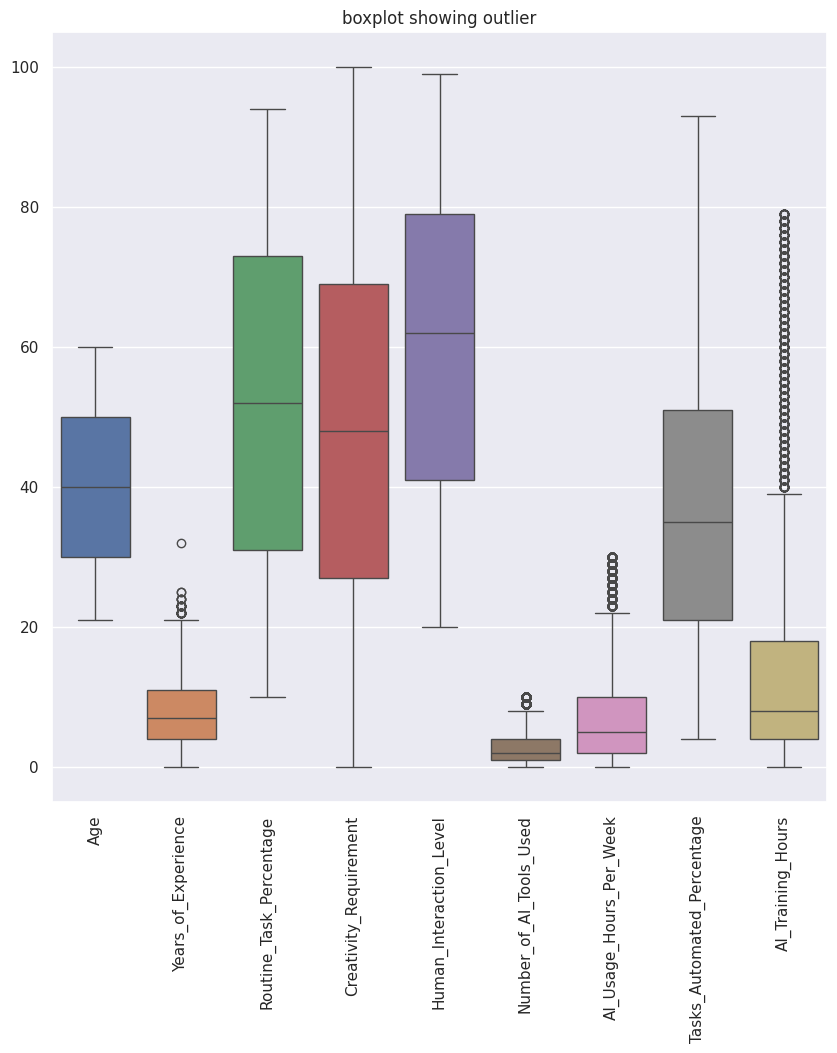

In [8]:
plt.figure(figsize = (10,10))
sns.boxplot(data = df,orient = 'v')
plt.xticks(rotation = 90)
plt.title('boxplot showing outlier')


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         20000 non-null  int64 
 1   Education_Level             20000 non-null  object
 2   Years_of_Experience         20000 non-null  int64 
 3   Industry                    20000 non-null  object
 4   Job_Role                    20000 non-null  object
 5   Company_Size                20000 non-null  object
 6   Job_Level                   20000 non-null  object
 7   Routine_Task_Percentage     20000 non-null  int64 
 8   Creativity_Requirement      20000 non-null  int64 
 9   Human_Interaction_Level     20000 non-null  int64 
 10  AI_Adoption_Level           20000 non-null  object
 11  Number_of_AI_Tools_Used     20000 non-null  int64 
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64 
 13  Tasks_Automated_Percentage  20000 non-null  in

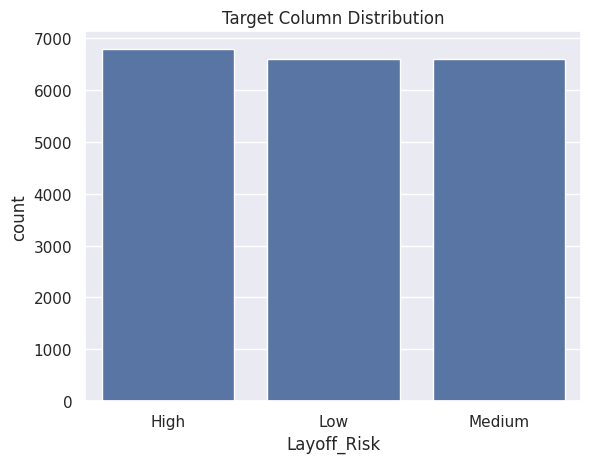

In [10]:
sns.countplot(x = 'Layoff_Risk',data = df)
plt.title('Target Column Distribution')
plt.show()

In [11]:
df.columns

Index(['Age', 'Education_Level', 'Years_of_Experience', 'Industry', 'Job_Role',
       'Company_Size', 'Job_Level', 'Routine_Task_Percentage',
       'Creativity_Requirement', 'Human_Interaction_Level',
       'AI_Adoption_Level', 'Number_of_AI_Tools_Used',
       'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage',
       'AI_Training_Hours', 'Layoff_Risk'],
      dtype='object')

In [ ]:
# step:2
# data preprocessing

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler


def preprocessing(df):

  df.drop(columns=['Age','Routine_Task_Percentage'],inplace=True)

  # segregate categorical and numerical colamns
  categorical_data = df.select_dtypes(include = 'object')
  numerical_data = df.select_dtypes(exclude = 'object')

  # encoding categorical data

  le = LabelEncoder()

  for i in categorical_data.columns:
    df[i] = le.fit_transform(df[i])

  # splite dataset x and y

  X = df.drop(columns = ['Layoff_Risk']) # seen data
  y = df['Layoff_Risk']                  # unseen data


  # split the dataset into train and test: seen and unseen data

  X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                   test_size = 0.2,
                                                   random_state = 1)

  # use scaling teck

  sc = RobustScaler()
  X_train = sc.fit_transform(X_train)
  X_test = sc.transform(X_test)

  return X_train,X_test,y_train,y_test

In [13]:
# step3
# model building

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import GridSearchCV

def model_building(X_train,X_test,y_train,y_test):

  model_results = {}

  model = {
      'DecisionTreeClassifier':DecisionTreeClassifier(),
      'RandomForestClassifier':RandomForestClassifier(),
      'LogisticRegression':LogisticRegression(),
      'KNeighborsClassifier':KNeighborsClassifier(),

  }
  for model_name,model in model.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print(model_name)
    print(classification_report(y_test,y_pred))

    score = accuracy_score(y_test,y_pred)
    model_results[model_name] = score

  return  model_results

In [14]:
def main():
  df = data_ingestion()
  X_train,X_test,y_train,y_test = preprocessing(df)
  scores = model_building(X_train,X_test,y_train,y_test)
  print('\nAll Model Scores:')



main()

DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      1336
           1       0.87      0.88      0.88      1346
           2       0.74      0.75      0.74      1318

    accuracy                           0.83      4000
   macro avg       0.83      0.83      0.83      4000
weighted avg       0.83      0.83      0.83      4000

RandomForestClassifier
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1336
           1       0.92      0.90      0.91      1346
           2       0.82      0.83      0.83      1318

    accuracy                           0.89      4000
   macro avg       0.89      0.89      0.89      4000
weighted avg       0.89      0.89      0.89      4000

LogisticRegression
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      1336
           1       0.87      0.86      0.87      1346
          

In [15]:
!pip install autogluon.tabular


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 514.8/514.8 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.4/248.4 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.7/90.7 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 10.1 MB/s eta 0:00:00


In [16]:
# AutoGluon : open-source automated machine learning
from autogluon.tabular import TabularDataset, TabularPredictor

label = 'Layoff_Risk'
predictor = TabularPredictor(label=label).fit(df)

No path specified. Models will be saved in: "AutogluonModels/ag-20260925_142159"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.6.3
Python Version:     3.13.15
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       10.98 GB / 12.67 GB (86.7%)
Disk Space Avail:   65.16 GB / 112.64 GB (57.9%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : Use this if you have a GPU. The go-to preset for best results, and t